In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
ff_df = pd.read_csv("F-F_Research_Data_5_Factors_2x3.csv", index_col=0, skiprows=3)
ff_df = ff_df[ff_df.index.astype(str).str.match(r"^\d{6}$")]
ff_df.index = pd.to_datetime(ff_df.index.astype(str), format="%Y%m")


ff_df.index = ff_df.index + pd.offsets.MonthEnd(0)
ff_df = ff_df.apply(pd.to_numeric, errors='coerce') / 100
ff_df = ff_df.loc[(ff_df.index >= '1964-01-01') & (ff_df.index < '2025-01-01')]
ff_df.rename(columns={"RF": "RiskFreeRate"}, inplace=True)
ff_df.tail()

,Mkt-RF,SMB,HML,RMW,CMA,RiskFreeRate
2024-08-31,0.0161,-0.0356,-0.0110,0.0073,0.0082,0.0048
2024-09-30,0.0173,-0.0091,-0.0277,0.0018,-0.0029,0.0040
2024-10-31,-0.0100,-0.0088,0.0086,-0.0140,0.0098,0.0039
2024-11-30,0.0649,0.0462,0.0015,-0.0231,-0.0205,0.0040
2024-12-31,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037


In [3]:
constituent_data = pd.read_csv('sp500_returns_with_tickers.csv')

# Parse 'date' column to datetime
constituent_data["date"] = pd.to_datetime(constituent_data["date"])

# Filter by date
constituent_data = constituent_data.loc[
    (constituent_data["date"] > '1963-12-31') &
    (constituent_data["date"] <= '2024-12-31')
]

# Set datetime index
constituent_data.set_index("date", inplace=True)

# Convert index to calendar month-end (regardless of Feb 28/29 or 30/31 issues)
constituent_data.index = constituent_data.index.to_period('M').to_timestamp('M')
tickers = constituent_data.columns
constituent_data.tail()

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
2024-08-31,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,-0.071535,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025
2024-11-30,NaN,NaN,NaN,NaN,NaN,0.101287,0.044149,NaN,NaN,0.127253,...,NaN,-0.045297,0.070945,-0.034608,0.208365,NaN,0.136817,NaN,0.013626,0.381469
2024-12-31,NaN,NaN,NaN,NaN,NaN,-0.098464,-0.004629,NaN,NaN,-0.076793,...,NaN,0.434045,-0.062506,-0.018765,-0.005997,NaN,-0.176142,NaN,-0.094742,0.170008


In [4]:
excess_returns = constituent_data.subtract(ff_df['RiskFreeRate'], axis=0)
factor_data = ff_df.drop(columns=["RiskFreeRate"])
factor_data["Mkt-RF"]

1964-01-31    0.0227
1964-02-29    0.0155
1964-03-31    0.0141
1964-04-30    0.0011
1964-05-31    0.0141
               ...  
2024-08-31    0.0161
2024-09-30    0.0173
2024-10-31   -0.0100
2024-11-30    0.0649
2024-12-31   -0.0315
Name: Mkt-RF, Length: 732, dtype: float64

In [5]:
merged_df = pd.concat([excess_returns, ff_df], axis=1)
merged_df

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,GNRC,QEP,CBOE,TSLA,Mkt-RF,SMB,HML,RMW,CMA,RiskFreeRate
1964-01-31,0.065548,-0.031846,0.066915,NaN,0.026083,NaN,NaN,NaN,-0.010371,NaN,...,NaN,NaN,NaN,NaN,0.0227,0.0010,0.0163,0.0021,0.0148,0.0030
1964-02-29,0.041174,0.032054,0.053400,NaN,-0.030861,NaN,NaN,NaN,0.037004,NaN,...,NaN,NaN,NaN,NaN,0.0155,0.0033,0.0281,0.0011,0.0081,0.0026
1964-03-31,-0.003100,0.044268,0.078339,NaN,0.067036,NaN,NaN,NaN,0.020710,NaN,...,NaN,NaN,NaN,NaN,0.0141,0.0141,0.0329,-0.0203,0.0298,0.0031
1964-04-30,0.000736,-0.032923,-0.016911,NaN,-0.049412,NaN,NaN,NaN,-0.038111,NaN,...,NaN,NaN,NaN,NaN,0.0011,-0.0148,-0.0054,-0.0132,-0.0113,0.0029
1964-05-31,-0.013470,0.025971,-0.020521,NaN,-0.040294,NaN,NaN,NaN,-0.019632,NaN,...,NaN,NaN,NaN,NaN,0.0141,-0.0062,0.0181,-0.0015,0.0013,0.0026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,NaN,NaN,NaN,NaN,NaN,0.008395,-0.005900,NaN,NaN,-0.076335,...,0.000660,NaN,0.117918,-0.082191,0.0161,-0.0356,-0.0110,0.0073,0.0082,0.0048
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.202030,0.027548,NaN,NaN,0.034948,...,0.011013,NaN,-0.006580,0.217942,0.0173,-0.0091,-0.0277,0.0018,-0.0029,0.0040
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.016576,-0.059559,NaN,NaN,0.004638,...,0.038081,NaN,0.038566,-0.048925,-0.0100,-0.0088,0.0086,-0.0140,0.0098,0.0039
2024-11-30,NaN,NaN,NaN,NaN,NaN,0.097287,0.040149,NaN,NaN,0.123253,...,0.132817,NaN,0.009626,0.377469,0.0649,0.0462,0.0015,-0.0231,-0.0205,0.0040


In [14]:
for col in merged_df.columns:
    print(col)

ACF
ABK
AMT
JAVA
AN
ORCL
MSFT
SDS
AYE
TROW
HON
EMC
AH
AMX
AHD
BEAM
ABC
PA
ACS
ACJ
LLTC
AMO
GENZ
SXCL
AR
AST
T
ZA
ASR
AD
A
ADM
AM
DG
SOV
ASF
AX
ARC
FRC
EHC
FI
CF
BYK
BLS
BX
BS
SGI
BG
KSE
CAL
BC
UIS
CERN
CMVT
CIT
BFO
CAH
CP
WCOM
JI
DELL
CDP
CNN
CO
CGG
C
CITA
CLU
KO
COT
CG
Unnamed: 72
CC
COG
CDR
CDNS
ED
BRL
CSC
CCC
CLL
XA
FICO
CUD
CELG
XRAY
DCN
FAST
MCAWA
DEL
DTE
DM
DD
ESB
EK
ETN
ET
SIVB
EJN
XOM
MGM
MXIM
FST
WM
APCC
BMC
FT
BGEN
KKR
CMCSK
CBO
GD
GE
LH
NVLS
PBCT
SIG
GM
NXPI
GSX
GMBL
GR
GUX
GN
GSW
Unnamed: 126
CHTR
HM
HW
LYB
GM.1
IL
TT
FRC.1
CPAY
MMI
RYI
IC
TRGP
IBM
NAV
MKG
NLSN
N
KMI
ITT
APO
HCA
HII
JWL
KSU
KYR
KN
KRA
KM
KSC
SR
LGT
MPC
LCE
LL
LN
MEI
MQ
MZ
FBIN
Unnamed: 167
MHT
XYL
AM.1
M
MAY
APTV
MYG
MTYRF
WPX
CPRI
GRH
Unnamed: 179
TRIP
EPAM
MRW
WEAR
NL
NAB
ENPH
CUE
PSX
NTY
META
CN
NKP
NOW
PANW
NFK
NTS
ADT
NP
PNR
KRFT
OLN
WDAY
OT
FANG
OI
PCG
PAC
ABBV
NCLH
ZTS
PC
PFK
PGL
PEP
MO
IQV
COP
PVH
CDW
NWSA
NWS
COTY
AMGN
MNK
PU
RCA
RDGE
RS
RJR
SJO
SLB
TWTR
ALLE
S
ANDW
HLT
SUO
SIM
L
SNSTA
PSU
SX
SR.1


In [6]:
def compute_rolling_betas_and_alpha(
    excess_returns_df,
    factor_df,
    portfolio_col,
    window=24,
    beta_MKT=True,
    beta_SMB=False,
    beta_HML=False,
    beta_RMW=False,
    beta_CMA=False,
    beta_Momentum=False
):
    """computes rolling betas and alphas"""
    factor_flags = {
        "Mkt-RF": beta_MKT,
        "SMB": beta_SMB,
        "HML": beta_HML,
        "RMW": beta_RMW,
        "CMA": beta_CMA,
        "Mom": beta_Momentum
    }

    selected_factors = [factor for factor, include in factor_flags.items() if include]

    results = {"alpha": []}
    for factor in selected_factors:
        results[f"beta_{factor}"] = []

    index = []

    for i in range(window, len(excess_returns_df)):
        y = excess_returns_df[portfolio_col].iloc[i - window:i]
        X = factor_df[selected_factors].iloc[i - window:i]

        #drop rows with nans
        valid = y.notna() & X.notna().all(axis=1)
        if valid.sum() < window:
            continue

        y = y[valid]
        X = X[valid]

        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()

        results["alpha"].append(model.params.get("const", float("nan")))
        for factor in selected_factors:
            results[f"beta_{factor}"].append(model.params.get(factor, float("nan")))

        index.append(excess_returns_df.index[i])

    return pd.DataFrame(results, index=index)

In [50]:
rolling_betas = []

for ticker in tickers:
    try:
        betas = compute_rolling_betas_and_alpha(
    excess_returns_df=excess_returns,
    factor_df=factor_data,
    portfolio_col=ticker,
    window=36,
    beta_MKT=True,
    beta_SMB=False,
    beta_HML=False,
    beta_RMW=False,
    beta_CMA=False
)
        betas["ticker"] = ticker
        rolling_betas.append(betas)
    except Exception as e:
        print(f"Error for {ticker}: {e}")

beta_df = pd.concat(rolling_betas).reset_index().rename(columns={"index": "date"})
beta_df

/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_78020/1345862056.py:21: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  beta_df = pd.concat(rolling_betas).reset_index().rename(columns={"index": "date"})


,date,alpha,beta_Mkt-RF,ticker
0,1967-01-31,0.004128,1.368421,ACF
1,1967-02-28,0.003717,1.403478,ACF
2,1967-03-31,0.001825,1.389848,ACF
3,1967-04-30,0.004618,1.509165,ACF
4,1967-05-31,0.004460,1.493075,ACF
...,...,...,...,...
302538,2024-08-31,0.004466,1.880977,TSLA
302539,2024-09-30,0.001002,1.864024,TSLA
302540,2024-10-31,0.001759,1.960413,TSLA
302541,2024-11-30,-0.006656,1.750627,TSLA


In [51]:
tech_stocks = [
    'ACN',
    'ADBE',
    'ADI',
    'AKAM',
    'AMAT',
    'AMCC',
    'AMD',
    'AMZN',
    'ANET',
    'ANSS',
    'AAPL',
    'APOL',
    'ATGE',
    'ATVI',
    'AVGO',
    'AVP',
    'AYI',
    'BEAM',
    'BRCM',
    'CDNS',
    'CERN',
    'CIEN',
    'CMCSA',
    'CMCSK',
    'COMS',
    'CPWR',
    'CRWD',
    'CSCO',
    'CSGP',
    'CTSH',
    'CTXS',
    'DECK',
    'DELL',
    'DXC',
    'EBAY',
    'EMC',
    'EPAM',
    'EQIX',
    'ETSY',
    'FICO',
    'FFIV',
    'FLIR',
    'FIS',
    'FTNT',
    'GDDY',
    'GOOG',
    'GOOGL',
    'GRMN',
    'GSX',
    'HPE',
    'IBM',
    'ILMN',
    'IMSI',
    'IN',
    'INFO',
    'INTC',
    'INTU',
    'ISRG',
    'IT',
    'JAVA',
    'JNPR',
    'KEYS',
    'KLAC',
    'LRCX',
    'LSI',
    'LU',
    'LUMN',
    'MCHP',
    'MET',
    'META',
    'MSFT',
    'MSI',
    'MTCH',
    'MXIM',
    'NDAQ',
    'NDSN',
    'NEC',
    'NFLX',
    'NVDA',
    'NVLS',
    'NXPI',
    'NYX',
    'ON',
    'ORCL',
    'PALM',
    'PANW',
    'PAYC',
    'PAYX',
    'PCS',
    'PLTR',
    'PLD',
    'PMCS',
    'PSFT',
    'PTC',
    'PYPL',
    'QCOM',
    'QLGC',
    'QRVO',
    'RHT',
    'ROK',
    'SAPE',
    'SBAC',
    'SEDG',
    'SEBL',
    'SGI',
    'SNPS',
    'SQD',
    'SWKS',
    'T',
    'TDC',
    'TER',
    'TLAB',
    'TMC',
    'TMO',
    'TRMB',
    'TSLA',
    'TTWO',
    'TWTR',
    'TYL',
    'TXN',
    'URBN',
    'VIAV',
    'VRT',
    'VRTX',
    'VZ',
    'WAT',
    'WDC',
    'WDAY',
    'XLNX',
    'YHOO',
    'ZBRA'
]

In [53]:
# Get the columns from your DataFrame
# Filter rows (not columns) where the ticker is in the tech list
filtered_tech_stocks = [ticker for ticker in tech_stocks if ticker in beta_df['ticker'].unique()]
beta_df = beta_df[beta_df['ticker'].isin(filtered_tech_stocks)]
beta_df

,date,alpha,beta_Mkt-RF,ticker
541,1995-08-31,0.015111,0.354156,JAVA
542,1995-09-30,0.020615,0.314378,JAVA
543,1995-10-31,0.017859,0.362641,JAVA
544,1995-11-30,0.023450,0.095291,JAVA
545,1995-12-31,0.025891,0.376281,JAVA
...,...,...,...,...
302538,2024-08-31,0.004466,1.880977,TSLA
302539,2024-09-30,0.001002,1.864024,TSLA
302540,2024-10-31,0.001759,1.960413,TSLA
302541,2024-11-30,-0.006656,1.750627,TSLA


In [55]:
beta_mkt_matrix = beta_df.pivot_table(
    index="date",
    columns="ticker",
    values="beta_Mkt-RF"
)

beta_mkt_matrix = beta_mkt_matrix.dropna(how='all')
beta_mkt_matrix

ticker,AAPL,ACN,ADBE,ADI,AKAM,AMAT,AMCC,AMD,AMZN,ANET,...,URBN,VIAV,VRT,VRTX,VZ,WAT,WDC,XLNX,YHOO,ZBRA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,NaN,1.222109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.082511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-02-28,NaN,0.982963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.865645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-03-31,NaN,0.974437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.895608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-04-30,NaN,0.944295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.808837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-05-31,NaN,0.917069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.788233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,1.171161,NaN,1.494454,1.099261,0.776125,1.680122,NaN,1.943506,1.357115,1.312389,...,NaN,NaN,NaN,0.396487,0.310563,1.136707,1.487337,NaN,NaN,1.673707
2024-09-30,1.171067,NaN,1.488751,1.113666,0.797852,1.690663,NaN,1.947727,1.347420,1.334195,...,NaN,NaN,NaN,0.403241,0.318375,1.128868,1.499712,NaN,NaN,1.661869
2024-10-31,1.156716,NaN,1.441335,1.146760,0.776126,1.700151,NaN,1.957747,1.354846,1.311284,...,NaN,NaN,NaN,0.336759,0.327200,1.088217,1.478663,NaN,NaN,1.652117


In [56]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def equal_abs_beta_contribution_weights(beta_row):
    #filter out nans and zero betas
    valid_betas = beta_row.dropna()
    valid_betas = valid_betas[valid_betas != 0]

    if valid_betas.empty:
        return pd.Series(dtype=float)

    betas = valid_betas.values
    n = len(betas)
    idx = valid_betas.index

    #objective function to minimize with target of 1/n
    def objective(w):
        contrib = w * betas
        return np.sum((contrib - 1/n)**2)

    #constraints: sum of weights = 1
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    ]

    #long only weights to mimic equal weight
    bounds = [(0, 1) for _ in range(n)]

    #start with inverted betas
    x0 = 1 / np.abs(betas)
    x0 = x0 / x0.sum()

    result = minimize(objective, x0, bounds=bounds, constraints=constraints)

    if not result.success:
        return pd.Series(dtype=float)

    weights = pd.Series(result.x, index=idx)

    full_weights = pd.Series(0.0, index=beta_row.index)
    full_weights.update(weights)

    return full_weights

In [57]:
from tqdm import tqdm
all_tickers = beta_mkt_matrix.columns
tqdm.pandas()

equal_abs_beta_weights = beta_mkt_matrix.progress_apply(
    lambda row: equal_abs_beta_contribution_weights(row).reindex(all_tickers, fill_value=0),
    axis=1
)

100%|██████████| 696/696 [00:04<00:00, 157.11it/s]


In [58]:
returns_aligned = constituent_data.loc[equal_abs_beta_weights.index, equal_abs_beta_weights.columns]

assert equal_abs_beta_weights.shape == returns_aligned.shape
assert equal_abs_beta_weights.columns.equals(returns_aligned.columns)
assert equal_abs_beta_weights.index.equals(returns_aligned.index)


weighted_returns = equal_abs_beta_weights * returns_aligned

equal_beta_portfolio_return = weighted_returns.sum(axis=1)

In [59]:
equal_beta_portfolio_return.index = equal_beta_portfolio_return.index - pd.offsets.MonthEnd(1) + pd.offsets.MonthBegin(1)

print(equal_beta_portfolio_return.head())

date
1967-01-01    0.097860
1967-02-01   -0.002708
1967-03-01    0.054405
1967-04-01    0.036327
1967-05-01   -0.046418
dtype: float64


In [60]:
sp500_returns = pd.read_csv("sp500_capweighted_returns.csv")
sp500_returns['date'] = pd.to_datetime(sp500_returns['date'])
sp500_returns.set_index('date', inplace=True)
sp500_returns.index = sp500_returns.index - pd.offsets.MonthEnd(1) + pd.offsets.MonthBegin(1)
sp500_returns

,0
date,
1960-01-01,-0.067093
1960-02-01,0.017111
1960-03-01,-0.010623
1960-04-01,-0.013724
1960-05-01,0.037913
...,...
2024-08-01,0.028116
2024-09-01,0.025856
2024-10-01,-0.004786


In [85]:
import pandas as pd
import numpy as np
from rich.jupyter import display
from torch.distributions.constraints import positive

data = pd.read_csv("sp500_returns_with_tickers.csv", index_col="date")
data.head()
data = data[filtered_tech_stocks]
cap_data = pd.read_csv("sp500_market_caps.csv", index_col="date")
cap_data = cap_data[filtered_tech_stocks]
cap_data.head()
cap_data = cap_data * 1000
cap_data.tail()
len(cap_data.columns)
cap_data_numeric = cap_data.apply(pd.to_numeric, errors='coerce')
cap_data_numeric = cap_data_numeric.fillna(0)
weight_data = cap_data_numeric.div(cap_data_numeric.sum(axis=1), axis=0)
row_sums = weight_data.sum(axis=1)
print(row_sums.head())
weight_data.tail()

date
1960-01-29    1.0
1960-02-29    1.0
1960-03-31    1.0
1960-04-29    1.0
1960-05-31    1.0
dtype: float64


,ACN,ADBE,ADI,AKAM,AMAT,AMCC,AMD,AMZN,ANET,ANSS,...,URBN,VIAV,VRT,VRTX,VZ,WAT,WDC,XLNX,YHOO,ZBRA
date,,,,,,,,,,,,,,,,,,,,,
2024-08-30,0.0,0.012403,0.005658,0.000749,0.007891,0.0,0.011667,0.090908,0.005387,0.001363,...,0.0,0.0,0.0,0.006211,0.008534,0.000998,0.001093,0.0,0.0,0.000864
2024-09-30,0.0,0.010685,0.005357,0.000713,0.007809,0.0,0.012484,0.091815,0.005653,0.001306,...,0.0,0.0,0.0,0.005619,0.008863,0.001002,0.001108,0.0,0.0,0.000895
2024-10-31,0.0,0.009941,0.005233,0.000719,0.007016,0.0,0.011044,0.092584,0.005735,0.001323,...,0.0,0.0,0.0,0.005790,0.008378,0.000906,0.001067,0.0,0.0,0.000931
2024-11-29,0.0,0.010162,0.004842,0.000632,0.006395,0.0,0.009960,0.097809,0.005719,0.001374,...,0.0,0.0,0.0,0.005394,0.008352,0.001022,0.001129,0.0,0.0,0.000939
2024-12-31,0.0,0.008491,0.004574,0.000623,0.005770,0.0,0.008503,0.100065,0.006040,0.001280,...,0.0,0.0,0.0,0.004498,0.007302,0.000955,0.000894,0.0,0.0,0.000864


In [90]:
data_numeric = data.apply(pd.to_numeric, errors='coerce').fillna(0)


sp500_returns = (data_numeric * weight_data).sum(axis=1)

active_mask = cap_data_numeric > 0


n_active_stocks = active_mask.sum(axis=1)


equal_weight_data = active_mask.div(n_active_stocks, axis=0)

sp500_ew_returns = (data_numeric * equal_weight_data).sum(axis=1)

# Optional: Check
print(sp500_ew_returns.head())
innovation_returns = sp500_returns - sp500_ew_returns
innovation_returns

date
1960-01-29   -0.047214
1960-02-29    0.051111
1960-03-31   -0.025614
1960-04-29    0.016453
1960-05-31    0.091407
dtype: float64


date
1960-01-29    0.036649
1960-02-29    0.027411
1960-03-31    0.038331
1960-04-29   -0.011502
1960-05-31   -0.032411
                ...   
2024-08-30   -0.004135
2024-09-30    0.017923
2024-10-31    0.016992
2024-11-29    0.003624
2024-12-31    0.066241
Length: 780, dtype: float64

In [61]:
common_index = sp500_returns.index.intersection(equal_beta_portfolio_return.index)
sp500_returns = sp500_returns.loc[common_index]
equal_beta_portfolio_return = equal_beta_portfolio_return.loc[common_index]
sp500_returns.columns = ["S&P 500 Return"]
equal_beta_portfolio_return = equal_beta_portfolio_return.to_frame(name="EBC Return")
equal_beta_portfolio_return

,EBC Return
date,
1967-01-01,0.097860
1967-02-01,-0.002708
1967-03-01,0.054405
1967-04-01,0.036327
1967-05-01,-0.046418
...,...
2024-08-01,0.020292
2024-09-01,0.022564
2024-10-01,-0.014917


In [62]:
spread = sp500_returns["S&P 500 Return"] - equal_beta_portfolio_return["EBC Return"]
spread = spread.to_frame(name="Spread Return")
spread

,Spread Return
date,
1967-01-01,-0.014444
1967-02-01,0.012747
1967-03-01,-0.010398
1967-04-01,0.011131
1967-05-01,0.001803
...,...
2024-08-01,0.007824
2024-09-01,0.003293
2024-10-01,0.010131


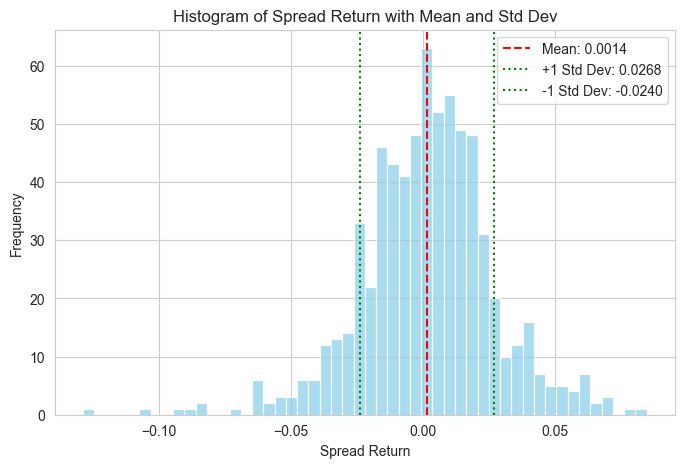

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

#mean and std
mean_val = spread['Spread Return'].mean()
std_val = spread['Spread Return'].std()

plt.figure(figsize=(8,5))
sns.histplot(spread['Spread Return'], bins=50, kde=False, color='skyblue', alpha=0.7)


plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')


plt.axvline(mean_val + std_val, color='green', linestyle=':', label=f'+1 Std Dev: {mean_val + std_val:.4f}')
plt.axvline(mean_val - std_val, color='green', linestyle=':', label=f'-1 Std Dev: {mean_val - std_val:.4f}')

plt.title("Histogram of Spread Return with Mean and Std Dev")
plt.xlabel("Spread Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
import numpy as np
import pandas as pd

def distance_from_equal_weights(row):
    #non nan and 0
    active = row[(row.notna()) & (row != 0)]

    if active.empty:
        return np.nan

    n_active = len(active)
    equal_w = 1 / n_active

    #equal weights
    equal_weights = pd.Series(equal_w, index=active.index)

    # euclidean distance
    dist = np.linalg.norm(active.values - equal_weights.values)
    return dist

#apply to each row
distance_series = equal_abs_beta_weights.apply(distance_from_equal_weights, axis=1)
distance_series.name = "Distance from Equal Weights (active stocks only)"


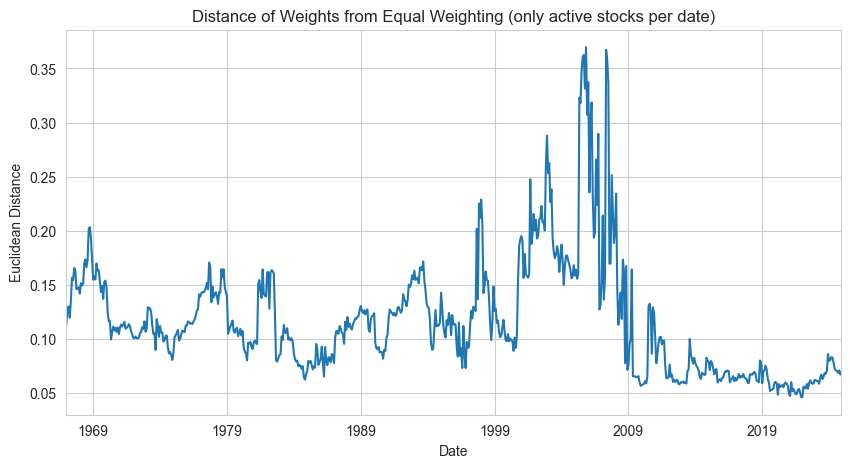

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
distance_series.plot()
plt.title("Distance of Weights from Equal Weighting (only active stocks per date)")
plt.ylabel("Euclidean Distance")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [66]:
max_dist_date = distance_series.idxmax()
weights_on_max_dist_date = equal_abs_beta_weights.loc[max_dist_date]
nonzero_weights = weights_on_max_dist_date[weights_on_max_dist_date != 0]
nonzero_weights

ticker
AAPL    0.017692
ADBE    0.014003
ADI     0.009895
AMAT    0.007958
AMCC    0.005382
AMD     0.005224
APOL    0.061238
AVP     0.380534
BEAM    0.023045
BRCM    0.004685
CIEN    0.006226
CPWR    0.006909
CSCO    0.010830
CTXS    0.008312
DELL    0.019462
DXC     0.018184
EBAY    0.010638
EMC     0.009309
IBM     0.018330
INTC    0.009340
INTU    0.019376
JAVA    0.006793
KLAC    0.007805
LSI     0.005087
LU      0.006167
LUMN    0.021828
MSFT    0.037226
MSI     0.012034
MXIM    0.008988
NVDA    0.004824
NVLS    0.008114
ORCL    0.012679
PAYX    0.023018
PMCS    0.004188
PTC     0.006983
QCOM    0.013989
QLGC    0.009370
SEBL    0.011197
T       0.021678
TER     0.005495
TLAB    0.010798
TMO     0.018610
TXN     0.008041
VIAV    0.007266
VZ      0.024637
WAT     0.011153
XLNX    0.009207
YHOO    0.016252
Name: 2005-11-30 00:00:00, dtype: float64

In [67]:
max_weight = nonzero_weights.max()
max_weight = nonzero_weights.max()
max_weight_ticker = nonzero_weights.idxmax()
print(f"Max weight: {max_weight:.4f} (Ticker: {max_weight_ticker})")

Max weight: 0.3805 (Ticker: AVP)


In [68]:
beta_value = beta_mkt_matrix.loc[max_dist_date, max_weight_ticker]
print(f"Beta of {max_weight_ticker} on {max_dist_date}: {beta_value}")

Beta of AVP on 2005-11-30 00:00:00: 0.0260591731590787


In [69]:
weighted_betas = equal_abs_beta_weights * beta_mkt_matrix

#contribtion data frame
print(f"Weighted betas: {weighted_betas}")

#weighted sum to see ecb beta
portfolio_beta = weighted_betas.sum(axis=1)
print(portfolio_beta.tail())


Weighted betas: ticker          AAPL       ACN      ADBE       ADI      AKAM      AMAT  AMCC  \
date                                                                           
1967-01-31       NaN  0.094077       NaN       NaN       NaN       NaN   NaN   
1967-02-28       NaN  0.092784       NaN       NaN       NaN       NaN   NaN   
1967-03-31       NaN  0.092198       NaN       NaN       NaN       NaN   NaN   
1967-04-30       NaN  0.092880       NaN       NaN       NaN       NaN   NaN   
1967-05-31       NaN  0.089276       NaN       NaN       NaN       NaN   NaN   
...              ...       ...       ...       ...       ...       ...   ...   
2024-08-31  0.017240       NaN  0.016932  0.017272  0.017916  0.016828   NaN   
2024-09-30  0.017052       NaN  0.016738  0.017079  0.017678  0.016616   NaN   
2024-10-31  0.017089       NaN  0.016899  0.017092  0.017705  0.016722   NaN   
2024-11-30  0.017334       NaN  0.017135  0.017333  0.017943  0.016923   NaN   
2024-12-31  0.016923    

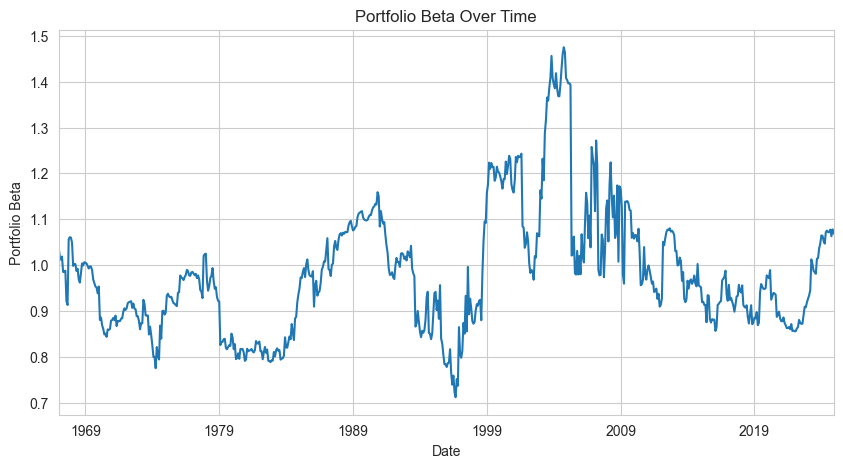

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
portfolio_beta.plot()
plt.title("Portfolio Beta Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Beta")
plt.grid(True)
plt.show()

In [71]:
cum_spread_return = np.log1p(spread["Spread Return"]).cumsum()
sp_cum_return = np.log1p(sp500_returns["S&P 500 Return"]).cumsum()
EBC_cum_return = np.log1p(equal_beta_portfolio_return["EBC Return"]).cumsum()
target_index = EBC_cum_return.index
target_index

DatetimeIndex(['1967-01-01', '1967-02-01', '1967-03-01', '1967-04-01',
               '1967-05-01', '1967-06-01', '1967-07-01', '1967-08-01',
               '1967-09-01', '1967-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='date', length=696, freq=None)

In [92]:
# preference = pd.read_csv("Preference Returns.csv", index_col=0, parse_dates=True)
# preference.index = pd.to_datetime(preference.index).to_period("M").to_timestamp()
# preference_cum_return = np.log1p(preference["Preference Return"]).cumsum()
# preference_cum_return = preference_cum_return.loc[target_index]

innovation_returns.index = pd.to_datetime(innovation_returns.index).to_period("M").to_timestamp()
innovation_cum_returns = np.log1p(innovation_returns).cumsum()
innovation_cum_returns = innovation_cum_returns.loc[target_index]

In [93]:
combined_returns = pd.DataFrame({
    "Spread Return": cum_spread_return,
    # "S&P Return": sp_cum_return,
    # "EBC Return": EBC_cum_return,
    "Preference": innovation_cum_returns
}, index=target_index)

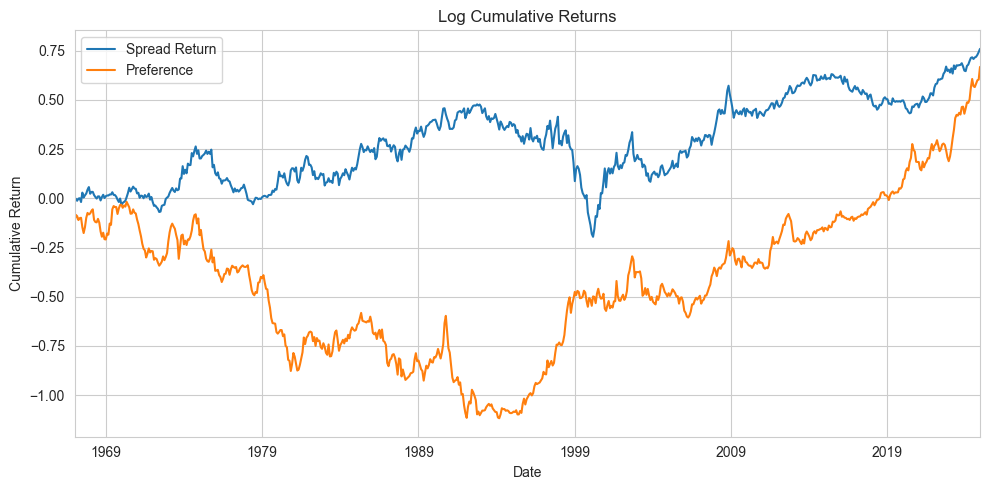

In [94]:
plt.figure(figsize=(10, 5))
combined_returns.plot(ax=plt.gca())
plt.title("Log Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()